<a href="https://colab.research.google.com/github/elifnurerdemir/DI725_Term_Project/blob/main/DI725_TermProject_Phase2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Environment Setup & Reproducibility

In [ ]:
# Install required packages (run once)
!pip install torch torchvision transformers pandas Pillow scikit-learn wandb --quiet

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from transformers import AutoTokenizer, AutoModel, ViTModel, ViTConfig
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, hamming_loss, classification_report
import matplotlib.pyplot as plt
import wandb

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42

def set_seed(seed: int) -> None:
    """Seed everything for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
print(f"Seed set to {SEED}")

Seed set to 42


## 0.1 Live Training Visualizer

`EpochVisualizer` renders a 2×3 dashboard inside the notebook after every epoch:
- **Row 1:** Training loss (cls + grounding), Validation Micro-F1, Validation Macro-F1
- **Row 2:** Hamming Loss, Dynamic Reliability Coefficient α (mean ± std), Per-class F1 bar chart

It uses `IPython.display.clear_output` to update in-place so the cell output does not scroll.

In [ ]:
from IPython.display import clear_output

class EpochVisualizer:
    """
    Live-updating training dashboard displayed inside a Jupyter notebook cell.

    Call `visualizer.update(epoch, train_metrics, val_metrics)` at the end of
    every epoch. The figure is redrawn in-place using clear_output so only
    the latest state is visible.

    Tracked metrics per epoch:
      train: cls_loss, grnd_loss
      val:   micro_f1, macro_f1, hamming, alpha_mean, alpha_std, f1_<class>
    """

    def __init__(self, classes: list, experiment_name: str):
        self.classes         = classes
        self.experiment_name = experiment_name

        # History buffers
        self.epochs      = []
        self.train_cls   = []
        self.train_grnd  = []
        self.val_micro   = []
        self.val_macro   = []
        self.val_hamming = []
        self.alpha_mean  = []
        self.alpha_std   = []
        self.per_class   = {cls: [] for cls in classes}  # val F1 per class

    def update(
        self,
        epoch: int,
        train_m: dict,
        val_m: dict,
    ) -> None:
        """Append metrics for this epoch and redraw the dashboard."""
        self.epochs.append(epoch)
        self.train_cls.append(train_m['cls_loss'])
        self.train_grnd.append(train_m['grnd_loss'])
        self.val_micro.append(val_m['micro_f1'])
        self.val_macro.append(val_m['macro_f1'])
        self.val_hamming.append(val_m['hamming'])
        self.alpha_mean.append(val_m['alpha_mean'])
        self.alpha_std.append(val_m['alpha_std'])
        for cls in self.classes:
            self.per_class[cls].append(val_m[f'f1_{cls}'])

        self._draw()

    def _draw(self) -> None:
        """Render the 2×3 dashboard and display it."""
        clear_output(wait=True)

        fig, axes = plt.subplots(2, 3, figsize=(15, 8))
        fig.suptitle(
            f'{self.experiment_name} – Training Dashboard  '
            f'(Epoch {self.epochs[-1]})',
            fontsize=13, fontweight='bold',
        )

        ep = self.epochs

        # ── (0,0) Training Loss components ───────────────────────────────────
        ax = axes[0, 0]
        ax.plot(ep, self.train_cls,  marker='o', linestyle='-',  label='Classification Loss')
        ax.plot(ep, self.train_grnd, marker='s', linestyle='--', label='Grounding Loss')
        ax.set_title('Training Loss')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.legend(fontsize=8)
        ax.grid(True, linestyle=':')

        # ── (0,1) Validation Micro-F1 ─────────────────────────────────────────
        ax = axes[0, 1]
        ax.plot(ep, self.val_micro, marker='^', linestyle='-', color='tab:green')
        ax.set_title('Validation Micro-F1')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Micro-F1')
        ax.set_ylim(0, 1)
        ax.annotate(
            f'{self.val_micro[-1]:.4f}',
            xy=(ep[-1], self.val_micro[-1]),
            xytext=(5, -12), textcoords='offset points', fontsize=9,
        )
        ax.grid(True, linestyle=':')

        # ── (0,2) Validation Macro-F1 ─────────────────────────────────────────
        ax = axes[0, 2]
        ax.plot(ep, self.val_macro, marker='D', linestyle='-', color='tab:orange')
        ax.set_title('Validation Macro-F1')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Macro-F1')
        ax.set_ylim(0, 1)
        ax.annotate(
            f'{self.val_macro[-1]:.4f}',
            xy=(ep[-1], self.val_macro[-1]),
            xytext=(5, -12), textcoords='offset points', fontsize=9,
        )
        ax.grid(True, linestyle=':')

        # ── (1,0) Hamming Loss ────────────────────────────────────────────────
        ax = axes[1, 0]
        ax.plot(ep, self.val_hamming, marker='x', linestyle='-', color='tab:red')
        ax.set_title('Validation Hamming Loss')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Hamming Loss')
        ax.set_ylim(0, max(self.val_hamming) * 1.2 + 1e-6)
        ax.annotate(
            f'{self.val_hamming[-1]:.4f}',
            xy=(ep[-1], self.val_hamming[-1]),
            xytext=(5, 5), textcoords='offset points', fontsize=9,
        )
        ax.grid(True, linestyle=':')

        # ── (1,1) Dynamic Reliability Coefficient α ───────────────────────────
        ax = axes[1, 1]
        means = np.array(self.alpha_mean)
        stds  = np.array(self.alpha_std)
        ax.plot(ep, means, marker='o', linestyle='-', color='tab:purple', label='Mean α')
        ax.fill_between(ep, means - stds, means + stds, alpha=0.25, color='tab:purple', label='±1 std')
        ax.axhline(0.5, color='grey', linestyle=':', linewidth=1, label='α=0.5 (balanced)')
        ax.set_title('Dynamic Reliability Coefficient α')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('α')
        ax.set_ylim(0, 1)
        ax.legend(fontsize=8)
        ax.grid(True, linestyle=':')

        # ── (1,2) Per-class F1 (latest epoch) ────────────────────────────────
        ax = axes[1, 2]
        latest_f1 = [self.per_class[cls][-1] for cls in self.classes]
        bars = ax.bar(
            self.classes, latest_f1,
            edgecolor='black',
            color=[
                'tab:green', 'tab:pink', 'tab:olive',
                'tab:orange', 'tab:brown', 'tab:gray', 'tab:blue'
            ],
        )
        ax.set_title(f'Per-Class F1 (Epoch {ep[-1]})')
        ax.set_ylabel('F1 Score')
        ax.set_ylim(0, 1)
        ax.tick_params(axis='x', rotation=20)
        for bar, val in zip(bars, latest_f1):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.02,
                f'{val:.2f}', ha='center', va='bottom', fontsize=7,
            )
        ax.grid(axis='y', linestyle=':')

        plt.tight_layout()
        plt.show()

## 1. Configuration

All hyperparameters and paths are centralised here. No magic numbers appear elsewhere in the notebook.

In [ ]:
# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_PATH      = r'/content/drive/MyDrive/DI725_project_dataset'   # update if needed
IMG_DIR        = os.path.join(BASE_PATH, 'images')
MASK_DIR       = os.path.join(BASE_PATH, 'masks')
LABELS_CSV     = os.path.join(BASE_PATH, 'binary_labels.csv')
CAPTIONS_CSV   = os.path.join(BASE_PATH, 'vision_captions_only.csv')

# ── Model & Training ─────────────────────────────────────────────────────────
DEVICE         = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CLASSES        = ['Tree', 'Shrub', 'Grass', 'Crop', 'Built-up', 'Barren', 'Water']
NUM_CLASSES    = len(CLASSES)
IMG_SIZE       = 224            # ViT-B/16 expects 224×224
PATCH_SIZE     = 16             # ViT-B/16 patch size
ATTN_GRID      = IMG_SIZE // PATCH_SIZE   # 14 – attention map spatial resolution
MAX_TEXT_LEN   = 128
BATCH_SIZE     = 32
NUM_EPOCHS     = 10
LEARNING_RATE  = 3e-5
VAL_SPLIT      = 0.15
TEST_SPLIT     = 0.10
ATTN_LOSS_W    = 0.1            # weight for the attention grounding loss term
VIT_EMBED_DIM  = 768
TEXT_EMBED_DIM = 768
CAPTION_COL    = 'vision_qwen3-vl-8b'
TEXT_MODEL_ID  = 'distilbert-base-uncased'

# ── Class colours (for mask decoding, Table 1 in the spec) ───────────────────
CLASS_RGB = {
    'Tree':     (0,   100,   0),
    'Shrub':    (255, 182, 193),
    'Grass':    (154, 205,  50),
    'Crop':     (255, 215,   0),
    'Built-up': (139,  69,  19),
    'Barren':   (211, 211, 211),
    'Water':    (0,     0, 255),
}

print(f"Device: {DEVICE}")
print(f"Attention grid: {ATTN_GRID}×{ATTN_GRID}")

Device: cuda
Attention grid: 14×14


## 2. Dataset

### 2.1 Mask Decoding

The RGB segmentation masks are decoded per-class into binary spatial maps.  
Each map is then resized to `ATTN_GRID × ATTN_GRID` to match the ViT attention resolution.

This produces a **per-class presence mask** that is later used as the supervision signal for Attention Grounding.

In [ ]:
def decode_mask(mask_path: str, class_rgb: dict, classes: list, grid: int) -> torch.Tensor:
    """
    Decode an RGB segmentation mask into a float tensor of shape (num_classes, grid, grid).
    Each channel contains a binary map indicating where that class is present,
    then bicubic-downsampled to the ViT attention resolution.

    Args:
        mask_path: Path to the RGB mask image.
        class_rgb: Mapping of class name to (R, G, B) tuple.
        classes:   Ordered list of class names.
        grid:      Spatial resolution for the output (ATTN_GRID).

    Returns:
        Tensor of shape (num_classes, grid, grid), values in [0, 1].
    """
    mask_img = np.array(Image.open(mask_path).convert('RGB'))  # (H, W, 3)
    H, W = mask_img.shape[:2]
    maps = []
    for cls in classes:
        r, g, b = class_rgb[cls]
        # Exact pixel match for each class colour
        binary = (
            (mask_img[:, :, 0] == r) &
            (mask_img[:, :, 1] == g) &
            (mask_img[:, :, 2] == b)
        ).astype(np.float32)  # (H, W)
        maps.append(binary)
    stacked = np.stack(maps, axis=0)  # (C, H, W)
    tensor  = torch.from_numpy(stacked).unsqueeze(0)  # (1, C, H, W)
    resized = F.interpolate(tensor, size=(grid, grid), mode='bilinear', align_corners=False)
    return resized.squeeze(0)  # (C, grid, grid)

### 2.2 Dataset Class

In [ ]:
class RemoteSensingDataset(Dataset):
    """
    Multi-modal remote sensing dataset.

    Returns a dict with:
      - image      : (3, 224, 224) normalised image tensor
      - input_ids  : (max_text_len,) token IDs from DistilBERT tokeniser
      - attn_mask  : (max_text_len,) attention mask for text
      - labels     : (num_classes,) binary multi-label targets
      - gt_attn    : (num_classes, ATTN_GRID, ATTN_GRID) per-class spatial mask
      - filename   : original filename string (for debugging)
    """

    def __init__(
        self,
        labels_df: pd.DataFrame,
        captions_df: pd.DataFrame,
        img_dir: str,
        mask_dir: str,
        class_rgb: dict,
        classes: list,
        attn_grid: int,
        transform=None,
        tokenizer=None,
        max_text_len: int = 128,
        caption_col: str = 'vision_qwen3-vl-8b',
    ):
        self.labels_df   = labels_df.reset_index(drop=True)
        # Index captions by filename for O(1) lookup
        self.captions    = captions_df.set_index('filename')[caption_col].to_dict()
        self.img_dir     = img_dir
        self.mask_dir    = mask_dir
        self.class_rgb   = class_rgb
        self.classes     = classes
        self.attn_grid   = attn_grid
        self.transform   = transform
        self.tokenizer   = tokenizer
        self.max_text_len = max_text_len

    def __len__(self) -> int:
        return len(self.labels_df)

    def __getitem__(self, idx: int) -> dict:
        row      = self.labels_df.iloc[idx]
        fname    = row['filename']

        # ── Image ────────────────────────────────────────────────────────────
        image = Image.open(os.path.join(self.img_dir, fname)).convert('RGB')
        if self.transform:
            image = self.transform(image)

        # ── Segmentation mask (decoded to per-class attention targets) ────────
        gt_attn = decode_mask(
            os.path.join(self.mask_dir, fname),
            self.class_rgb, self.classes, self.attn_grid
        )  # (num_classes, grid, grid)

        # ── Caption ──────────────────────────────────────────────────────────
        caption  = str(self.captions.get(fname, ''))
        encoding = self.tokenizer(
            caption,
            padding='max_length',
            truncation=True,
            max_length=self.max_text_len,
            return_tensors='pt',
        )

        # ── Labels ───────────────────────────────────────────────────────────
        labels = torch.tensor(row[self.classes].values.astype(float), dtype=torch.float32)

        return {
            'image':     image,
            'input_ids': encoding['input_ids'].squeeze(0),
            'attn_mask': encoding['attention_mask'].squeeze(0),
            'labels':    labels,
            'gt_attn':   gt_attn,
            'filename':  fname,
        }

### 2.3 Data Loading

In [ ]:
def build_dataloaders(
    labels_csv: str,
    captions_csv: str,
    img_dir: str,
    mask_dir: str,
    class_rgb: dict,
    classes: list,
    attn_grid: int,
    text_model_id: str,
    batch_size: int,
    val_split: float,
    test_split: float,
    max_text_len: int,
    caption_col: str,
    seed: int,
):
    """Load CSVs, split, and return (train_loader, val_loader, test_loader)."""
    labels_df   = pd.read_csv(labels_csv)
    captions_df = pd.read_csv(captions_csv)

    tokenizer = AutoTokenizer.from_pretrained(text_model_id)

    img_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])

    # Stratified split is not straightforward for multi-label, so we use random
    train_val_df, test_df = train_test_split(labels_df, test_size=test_split,  random_state=seed)
    train_df,    val_df  = train_test_split(train_val_df, test_size=val_split / (1 - test_split), random_state=seed)

    dataset_kwargs = dict(
        captions_df=captions_df,
        img_dir=img_dir, mask_dir=mask_dir,
        class_rgb=class_rgb, classes=classes,
        attn_grid=attn_grid,
        transform=img_transform,
        tokenizer=tokenizer,
        max_text_len=max_text_len,
        caption_col=caption_col,
    )

    train_loader = DataLoader(
        RemoteSensingDataset(labels_df=train_df, **dataset_kwargs),
        batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True,
    )
    val_loader = DataLoader(
        RemoteSensingDataset(labels_df=val_df, **dataset_kwargs),
        batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True,
    )
    test_loader = DataLoader(
        RemoteSensingDataset(labels_df=test_df, **dataset_kwargs),
        batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True,
    )

    print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
    return train_loader, val_loader, test_loader


train_loader, val_loader, test_loader = build_dataloaders(
    labels_csv=LABELS_CSV, captions_csv=CAPTIONS_CSV,
    img_dir=IMG_DIR, mask_dir=MASK_DIR,
    class_rgb=CLASS_RGB, classes=CLASSES,
    attn_grid=ATTN_GRID, text_model_id=TEXT_MODEL_ID,
    batch_size=BATCH_SIZE, val_split=VAL_SPLIT, test_split=TEST_SPLIT,
    max_text_len=MAX_TEXT_LEN, caption_col=CAPTION_COL,
    seed=SEED,
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train: 7500 | Val: 1500 | Test: 1000


## 3. Model Architecture

### 3.1 Conceptual Definitions

**Dynamic Reliability Coefficient (α)**  
The gate network produces a scalar α ∈ (0, 1) per sample, conditioned on *both* the visual embedding v and the text embedding t:
```
α = σ( W₂ · ReLU( W₁ · [v; t] + b₁ ) + b₂ )
```
The fused representation is then:
```
f = α · v + (1 − α) · t
```
A high α means the model trusts the image more; a low α means it relies on the caption.  
This is *dynamic* because it adapts per sample rather than using a fixed mixing ratio.

**Attention Grounding Loss**  
For each class c, we extract the ViT's last-layer self-attention averaged over heads, producing a spatial attention map A ∈ ℝ^(grid×grid). We supervise A toward the decoded segmentation mask M_c using MSE:
```
L_grounding = (1/C) Σ_c MSE(A_c, M_c)
```
The total loss combines classification and grounding:  
```
L_total = L_BCE + λ · L_grounding    (λ = ATTN_LOSS_W)
```

**Performance Metrics**  
- **Micro-F1**: primary metric (treats all class-sample pairs equally)
- **Macro-F1**: secondary metric (penalises poor performance on rare classes)
- **Hamming Loss**: fraction of wrong label predictions
- **Per-class F1**: enables class-level analysis in the ablation study

### 3.2 ViT Attention Extraction

We register a forward hook on the **last encoder block's attention module** of `google/vit-base-patch16-224`.
The hook captures the raw attention weights before the softmax dropout.
The resulting tensor has shape `(batch, heads, tokens, tokens)`.

The CLS token attends to all patch tokens, so the CLS row (index 0) of each head gives us a 196-length spatial attention vector, which we reshape to `(14, 14)` and average over all heads.

In [ ]:
class ViTWithAttention(nn.Module):
    """
    Wraps HuggingFace ViTModel and exposes the last-layer CLS attention map.

    The ViTModel must be instantiated with output_attentions=True so that
    all attention weight tensors are returned from the forward pass.
    We use the final layer's attention, averaged across heads,
    and select the row corresponding to the CLS token (index 0).

    Returns:
        cls_feat   : (batch, 768)                 – CLS token embedding
        attn_map   : (batch, ATTN_GRID, ATTN_GRID) – spatial attention
    """

    def __init__(self, model_id: str = 'google/vit-base-patch16-224', attn_grid: int = 14):
        super().__init__()
        self.vit      = ViTModel.from_pretrained(model_id, output_attentions=True)
        self.attn_grid = attn_grid

    def forward(self, pixel_values: torch.Tensor):
        outputs   = self.vit(pixel_values=pixel_values)
        cls_feat  = outputs.last_hidden_state[:, 0]          # (B, 768)

        # outputs.attentions: tuple of (B, heads, tokens, tokens) for each layer
        last_attn = outputs.attentions[-1]                   # (B, 12, 197, 197)
        # CLS token (row 0) attending to patch tokens (columns 1:)
        cls_attn  = last_attn[:, :, 0, 1:]                  # (B, 12, 196)
        # Average over heads
        attn_mean = cls_attn.mean(dim=1)                     # (B, 196)
        # Normalise to [0, 1] per sample for stable supervision
        attn_min  = attn_mean.min(dim=1, keepdim=True).values
        attn_max  = attn_mean.max(dim=1, keepdim=True).values
        attn_norm = (attn_mean - attn_min) / (attn_max - attn_min + 1e-8)
        # Reshape to spatial grid
        attn_map  = attn_norm.reshape(-1, self.attn_grid, self.attn_grid)  # (B, 14, 14)

        return cls_feat, attn_map

### 3.3 Full Gated Multi-Modal Model

In [ ]:
class GatedMultiModalModel(nn.Module):
    """
    Multi-modal land cover classifier with:
      - ViT-B/16 image encoder with real attention extraction
      - DistilBERT text encoder
      - Dynamic Reliability Gate (produces α per sample)
      - Attention Grounding (ViT attention supervised by segmentation masks)

    Forward returns:
      logits   : (B, num_classes)            – raw classification scores
      alpha    : (B, 1)                      – reliability coefficient
      attn_map : (B, ATTN_GRID, ATTN_GRID)  – normalised spatial attention
    """

    def __init__(
        self,
        num_classes: int,
        vit_embed_dim: int   = 768,
        text_embed_dim: int  = 768,
        gate_hidden_dim: int = 256,
        attn_grid: int       = 14,
        text_model_id: str   = 'distilbert-base-uncased',
    ):
        super().__init__()

        # ── Vision encoder ───────────────────────────────────────────────────
        self.vision_encoder = ViTWithAttention(attn_grid=attn_grid)

        # ── Text encoder ─────────────────────────────────────────────────────
        self.text_encoder = AutoModel.from_pretrained(text_model_id)

        # ── Dynamic Reliability Gate ──────────────────────────────────────────
        # Produces α ∈ (0,1) from the concatenation of both embeddings
        self.gate = nn.Sequential(
            nn.Linear(vit_embed_dim + text_embed_dim, gate_hidden_dim),
            nn.ReLU(),
            nn.Linear(gate_hidden_dim, 1),
            nn.Sigmoid(),
        )

        # ── Classification head ───────────────────────────────────────────────
        self.classifier = nn.Linear(vit_embed_dim, num_classes)

    def forward(
        self,
        pixel_values: torch.Tensor,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor,
    ):
        # ── Visual features & real attention map ─────────────────────────────
        v_feat, attn_map = self.vision_encoder(pixel_values)  # (B,768), (B,14,14)

        # ── Text features (CLS token) ─────────────────────────────────────────
        t_out  = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask)
        t_feat = t_out.last_hidden_state[:, 0]                # (B, 768)

        # ── Dynamic Reliability Coefficient α ────────────────────────────────
        alpha  = self.gate(torch.cat([v_feat, t_feat], dim=1))  # (B, 1)

        # ── Weighted fusion ───────────────────────────────────────────────────
        fused  = alpha * v_feat + (1.0 - alpha) * t_feat       # (B, 768)

        # ── Classification ───────────────────────────────────────────────────
        logits = self.classifier(fused)                         # (B, num_classes)

        return logits, alpha, attn_map

## 4. Benchmarking Baseline

### Baseline Design

To evaluate the contribution of the proposed method, we compare it against a **Vision-Only Baseline**:
- Uses ViT-B/16 image features only (no text, no gate, no attention grounding)
- Classification head is identical to the proposed model
- Trained with the same hyperparameters

This isolates the contribution of the text modality, the reliability gate, and the attention grounding loss.

In [ ]:
class VisionOnlyBaseline(nn.Module):
    """
    Baseline: ViT-B/16 image features → linear classifier.
    No text modality, no reliability gate, no attention grounding.
    """

    def __init__(self, num_classes: int, attn_grid: int = 14):
        super().__init__()
        self.vision_encoder = ViTWithAttention(attn_grid=attn_grid)
        self.classifier     = nn.Linear(768, num_classes)

    def forward(
        self,
        pixel_values: torch.Tensor,
        input_ids: torch.Tensor = None,      # not used – kept for interface consistency
        attention_mask: torch.Tensor = None,
    ):
        v_feat, attn_map = self.vision_encoder(pixel_values)
        logits           = self.classifier(v_feat)
        alpha            = torch.ones(v_feat.shape[0], 1, device=v_feat.device)  # α=1 (pure vision)
        return logits, alpha, attn_map

## 5. Training Infrastructure

In [ ]:
def compute_metrics(preds: np.ndarray, targets: np.ndarray, classes: list) -> dict:
    """
    Compute multi-label classification metrics.

    Args:
        preds:   (N, C) binary predictions
        targets: (N, C) binary ground-truth
        classes: list of class names

    Returns:
        dict with micro_f1, macro_f1, hamming_loss, and per-class F1 scores
    """
    metrics = {
        'micro_f1':    f1_score(targets, preds, average='micro',  zero_division=0),
        'macro_f1':    f1_score(targets, preds, average='macro',  zero_division=0),
        'hamming':     hamming_loss(targets, preds),
    }
    per_class_f1 = f1_score(targets, preds, average=None, zero_division=0)
    for cls, score in zip(classes, per_class_f1):
        metrics[f'f1_{cls}'] = score
    return metrics


def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer,
    device: torch.device,
    attn_loss_w: float,
    classes: list,
    is_train: bool = True,
    use_attn_grounding: bool = True,
) -> dict:
    """
    Run one epoch (training or evaluation).

    Returns a dict with loss components and classification metrics.
    """
    model.train(is_train)
    total_cls_loss   = 0.0
    total_grnd_loss  = 0.0
    all_preds, all_targets = [], []
    alpha_list = []

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for batch in loader:
            imgs     = batch['image'].to(device, non_blocking=True)
            ids      = batch['input_ids'].to(device, non_blocking=True)
            attn_msk = batch['attn_mask'].to(device, non_blocking=True)
            labels   = batch['labels'].to(device, non_blocking=True)
            gt_attn  = batch['gt_attn'].to(device, non_blocking=True)  # (B, C, grid, grid)

            if is_train:
                optimizer.zero_grad()

            logits, alpha, attn_map = model(imgs, ids, attn_msk)

            # ── Classification loss ───────────────────────────────────────────
            cls_loss = F.binary_cross_entropy_with_logits(logits, labels)

            # ── Attention Grounding loss ──────────────────────────────────────
            # attn_map: (B, grid, grid) — a single map for the whole image
            # gt_attn:  (B, C, grid, grid) — per-class masks
            # We compare the unified attention against the union of masks for
            # present classes, weighted by class presence.
            grnd_loss = torch.tensor(0.0, device=device)
            if use_attn_grounding:
                # Build a presence-weighted union mask
                presence = labels.unsqueeze(-1).unsqueeze(-1)  # (B, C, 1, 1)
                union_gt = (gt_attn * presence).max(dim=1).values  # (B, grid, grid)
                grnd_loss = F.mse_loss(attn_map, union_gt)

            loss = cls_loss + attn_loss_w * grnd_loss

            if is_train:
                loss.backward()
                optimizer.step()

            total_cls_loss  += cls_loss.item()
            total_grnd_loss += grnd_loss.item()

            preds = (torch.sigmoid(logits) > 0.5).int().cpu().numpy()
            all_preds.append(preds)
            all_targets.append(labels.cpu().numpy())
            alpha_list.append(alpha.detach().cpu())

    all_preds   = np.vstack(all_preds)
    all_targets = np.vstack(all_targets)
    alpha_all   = torch.cat(alpha_list).squeeze(1).numpy()

    metrics = compute_metrics(all_preds, all_targets, classes)
    n       = len(loader)
    metrics['cls_loss']  = total_cls_loss  / n
    metrics['grnd_loss'] = total_grnd_loss / n
    metrics['alpha_mean'] = float(alpha_all.mean())
    metrics['alpha_std']  = float(alpha_all.std())

    return metrics

## 6. Experiment Runner

Each experiment is tagged in WandB with its configuration. Results are saved locally as a CSV and also logged to WandB.

In [ ]:
def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    num_epochs: int,
    lr: float,
    attn_loss_w: float,
    device: torch.device,
    classes: list,
    use_attn_grounding: bool,
    experiment_name: str,
    wandb_project: str = 'DI725_Phase2',
) -> list:
    """
    Train and validate a model, logging to WandB.

    Returns a list of per-epoch metric dicts (validation metrics).
    """
    run = wandb.init(
        project=wandb_project,
        name=experiment_name,
        config=dict(
            num_epochs=num_epochs,
            lr=lr,
            attn_loss_w=attn_loss_w,
            use_attn_grounding=use_attn_grounding,
            batch_size=BATCH_SIZE,
            seed=SEED,
        ),
        reinit=True,
    )

    optimizer  = torch.optim.AdamW(model.parameters(), lr=lr)
    scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    model.to(device)

    # ── Live visualizer ───────────────────────────────────────────────────────
    viz = EpochVisualizer(classes=classes, experiment_name=experiment_name)

    history = []
    best_f1 = 0.0

    for epoch in range(1, num_epochs + 1):
        train_m = run_epoch(
            model, train_loader, optimizer, device,
            attn_loss_w, classes, is_train=True,
            use_attn_grounding=use_attn_grounding,
        )
        val_m = run_epoch(
            model, val_loader, None, device,
            attn_loss_w, classes, is_train=False,
            use_attn_grounding=use_attn_grounding,
        )
        scheduler.step()

        # ── WandB logging ─────────────────────────────────────────────────────
        log_dict = {
            'epoch': epoch,
            **{f'train/{k}': v for k, v in train_m.items()},
            **{f'val/{k}':   v for k, v in val_m.items()},
        }
        wandb.log(log_dict)
        history.append({'epoch': epoch, **val_m})

        # ── Live dashboard update (replaces previous epoch's plot) ────────────
        viz.update(epoch, train_m, val_m)

        if val_m['micro_f1'] > best_f1:
            best_f1 = val_m['micro_f1']
            torch.save(model.state_dict(), f'{experiment_name}_best.pt')

    print(f"\n[{experiment_name}] Training complete. Best Val Micro-F1: {best_f1:.4f}")
    wandb.finish()
    return history

## 7. Run Experiments

### Experiment Design

| Experiment | Model | Grounding | Purpose |
|---|---|---|---|
| A | VisionOnly Baseline | ✗ | Lower bound; no text, no gate |
| B | Gated Multi-Modal | ✗ | Effect of text + gate alone |
| C | Gated Multi-Modal | ✓ | Full proposed method |

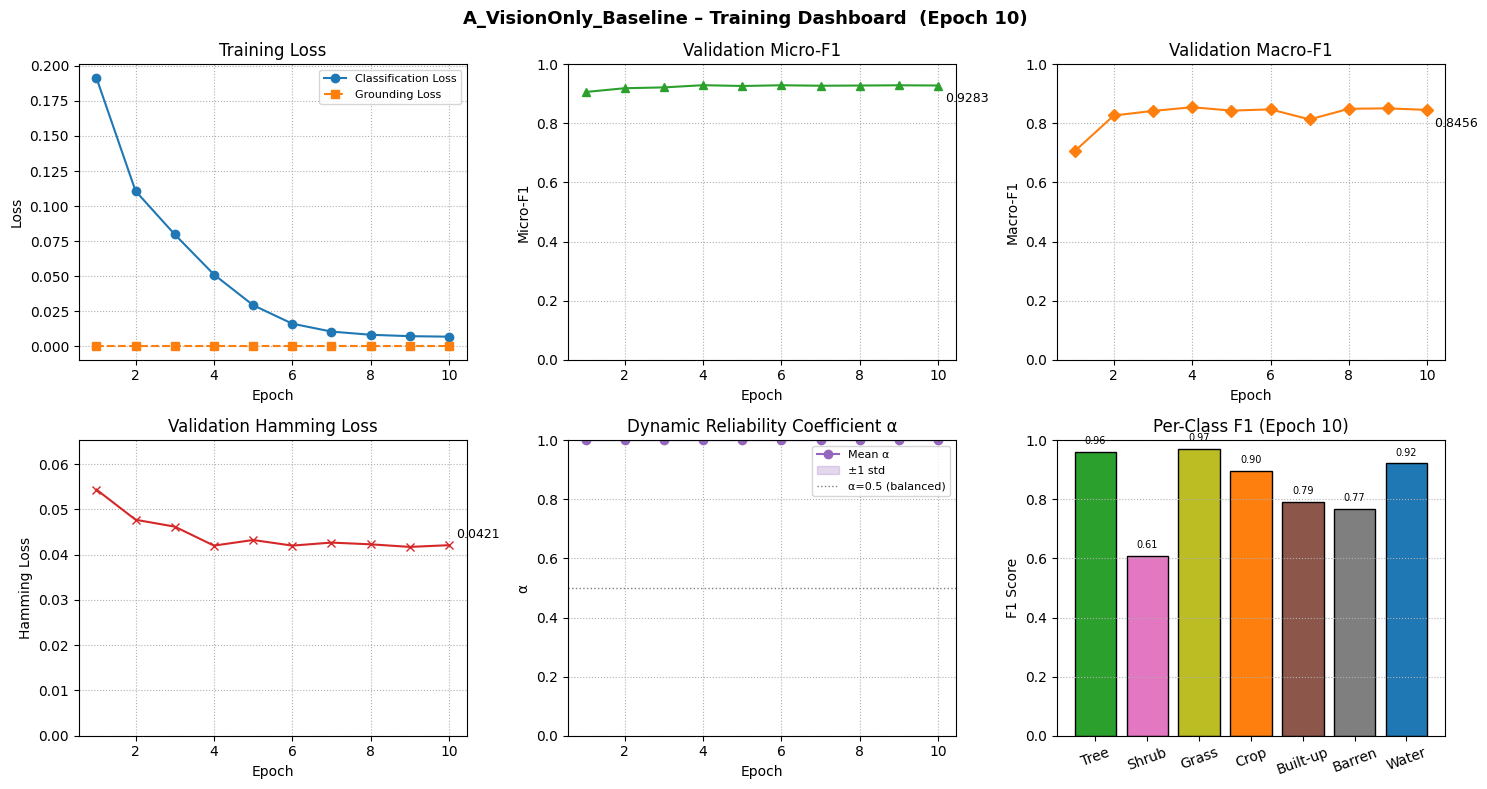


[A_VisionOnly_Baseline] Training complete. Best Val Micro-F1: 0.9294


epoch,▁▂▃▃▄▅▆▆▇█
train/alpha_mean,▁▁▁▁▁▁▁▁▁▁
train/alpha_std,▁▁▁▁▁▁▁▁▁▁
train/cls_loss,█▅▄▃▂▁▁▁▁▁
train/f1_Barren,▁▅▆▇██████
train/f1_Built-up,▁▆▇███████
train/f1_Crop,▁▄▅▇██████
train/f1_Grass,▁▄▅▆▇█████
train/f1_Shrub,▁▃▅▆▇█████
train/f1_Tree,▁▅▆▇██████
+19,...


In [ ]:
# ── WandB login (run once per session) ───────────────────────────────────────
# wandb.login()   # uncomment and paste your API key when prompted

# ── Experiment A: Vision-Only Baseline ───────────────────────────────────────
set_seed(SEED)
model_A = VisionOnlyBaseline(num_classes=NUM_CLASSES, attn_grid=ATTN_GRID)
history_A = train_model(
    model=model_A,
    train_loader=train_loader, val_loader=val_loader,
    num_epochs=NUM_EPOCHS, lr=LEARNING_RATE,
    attn_loss_w=ATTN_LOSS_W, device=DEVICE,
    classes=CLASSES,
    use_attn_grounding=False,
    experiment_name='A_VisionOnly_Baseline',
)

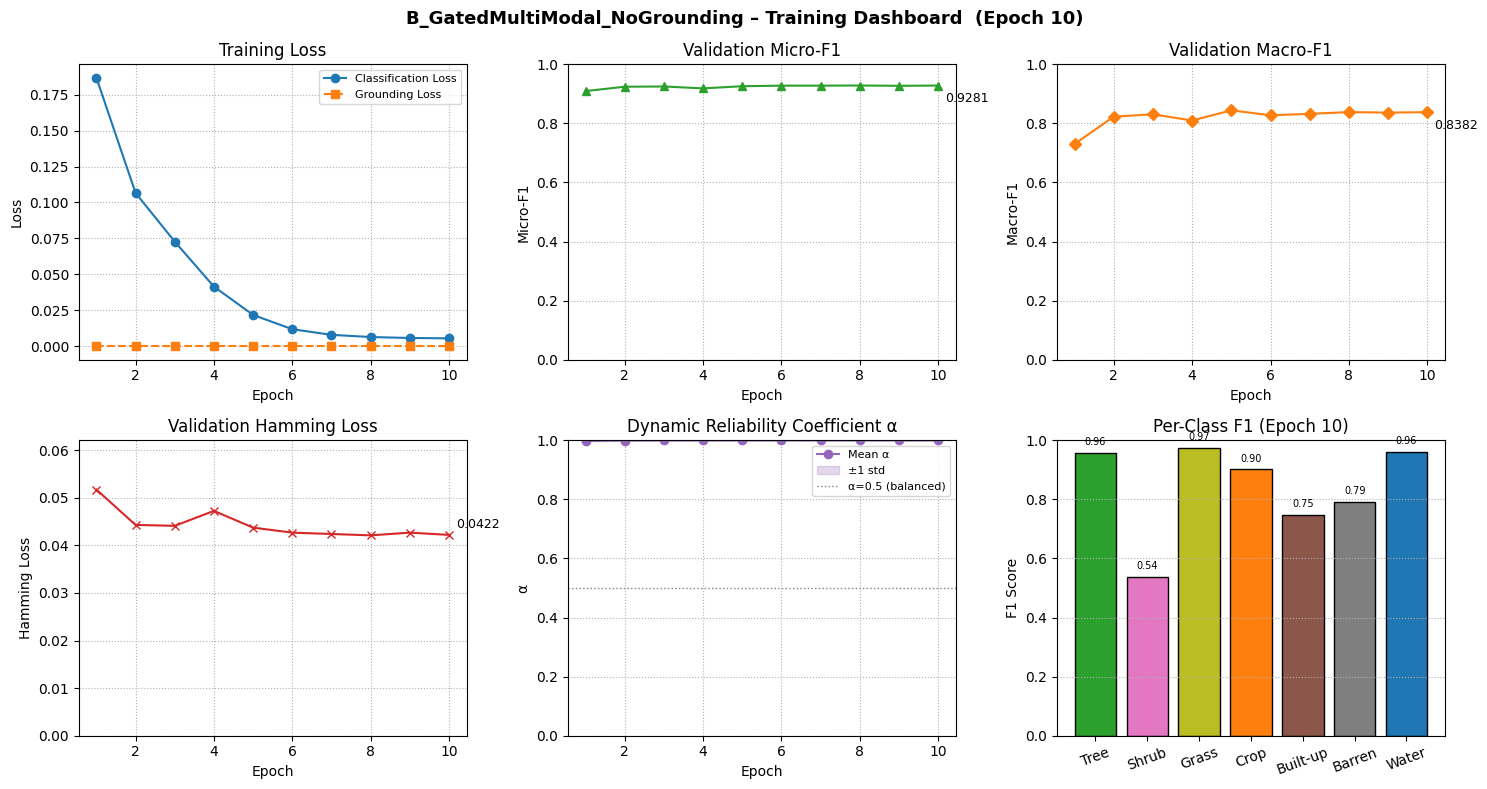


[B_GatedMultiModal_NoGrounding] Training complete. Best Val Micro-F1: 0.9283


epoch,▁▂▃▃▄▅▆▆▇█
train/alpha_mean,▁█████████
train/alpha_std,█▁▁▁▁▁▁▁▁▁
train/cls_loss,█▅▄▂▂▁▁▁▁▁
train/f1_Barren,▁▄▆▇██████
train/f1_Built-up,▁▆▇███████
train/f1_Crop,▁▄▆▇██████
train/f1_Grass,▁▄▅▇██████
train/f1_Shrub,▁▄▅▇██████
train/f1_Tree,▁▄▆▇██████
+19,...


In [ ]:
# ── Experiment B: Gated Multi-Modal (no grounding) ────────────────────────────
set_seed(SEED)
model_B = GatedMultiModalModel(
    num_classes=NUM_CLASSES, attn_grid=ATTN_GRID,
    text_model_id=TEXT_MODEL_ID,
)
history_B = train_model(
    model=model_B,
    train_loader=train_loader, val_loader=val_loader,
    num_epochs=NUM_EPOCHS, lr=LEARNING_RATE,
    attn_loss_w=ATTN_LOSS_W, device=DEVICE,
    classes=CLASSES,
    use_attn_grounding=False,
    experiment_name='B_GatedMultiModal_NoGrounding',
)

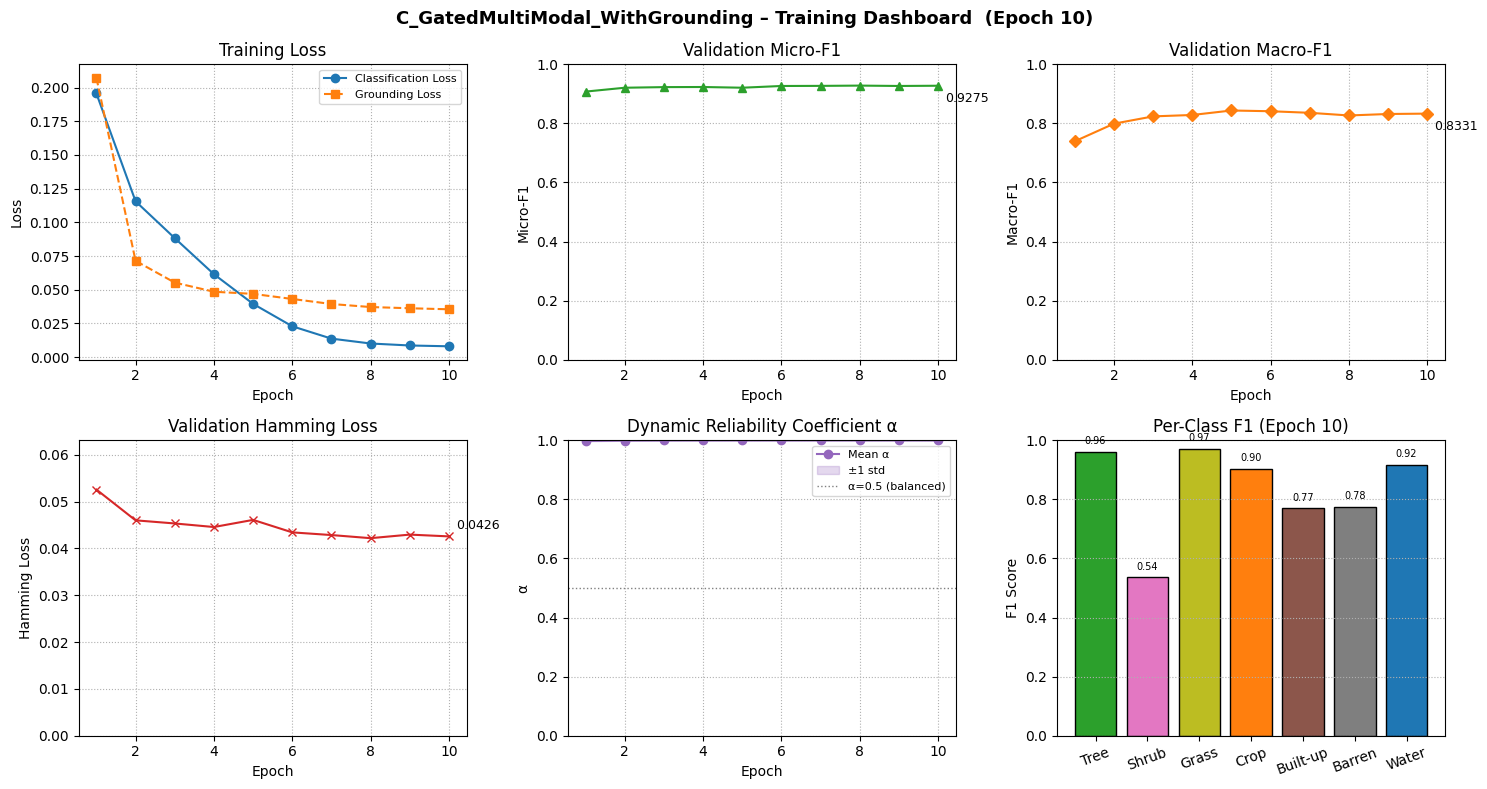


[C_GatedMultiModal_WithGrounding] Training complete. Best Val Micro-F1: 0.9280


epoch,▁▂▃▃▄▅▆▆▇█
train/alpha_mean,▁█████████
train/alpha_std,█▁▁▁▁▁▁▁▁▁
train/cls_loss,█▅▄▃▂▂▁▁▁▁
train/f1_Barren,▁▄▅▆▇█████
train/f1_Built-up,▁▆▇███████
train/f1_Crop,▁▄▅▆▇█████
train/f1_Grass,▁▃▅▆▇▇████
train/f1_Shrub,▁▃▅▆▇▇████
train/f1_Tree,▁▄▆▇▇█████
+19,...


In [ ]:
# ── Experiment C: Full Proposed Method (with grounding) ───────────────────────
set_seed(SEED)
model_C = GatedMultiModalModel(
    num_classes=NUM_CLASSES, attn_grid=ATTN_GRID,
    text_model_id=TEXT_MODEL_ID,
)
history_C = train_model(
    model=model_C,
    train_loader=train_loader, val_loader=val_loader,
    num_epochs=NUM_EPOCHS, lr=LEARNING_RATE,
    attn_loss_w=ATTN_LOSS_W, device=DEVICE,
    classes=CLASSES,
    use_attn_grounding=True,
    experiment_name='C_GatedMultiModal_WithGrounding',
)

## 8. Results

In [ ]:
def eval_on_test(
    model: nn.Module,
    test_loader: DataLoader,
    device: torch.device,
    attn_loss_w: float,
    classes: list,
    use_attn_grounding: bool,
    model_name: str,
) -> dict:
    """Load best checkpoint and evaluate on the held-out test set."""
    ckpt_path = f'{model_name}_best.pt'
    if os.path.exists(ckpt_path):
        model.load_state_dict(torch.load(ckpt_path, map_location=device))
        print(f"Loaded best checkpoint: {ckpt_path}")
    model.to(device)
    metrics = run_epoch(
        model, test_loader, None, device,
        attn_loss_w, classes, is_train=False,
        use_attn_grounding=use_attn_grounding,
    )
    return metrics


results = {}
results['A_VisionOnly'] = eval_on_test(
    model_A, test_loader, DEVICE, ATTN_LOSS_W, CLASSES,
    use_attn_grounding=False, model_name='A_VisionOnly_Baseline'
)
results['B_GatedNoGround'] = eval_on_test(
    model_B, test_loader, DEVICE, ATTN_LOSS_W, CLASSES,
    use_attn_grounding=False, model_name='B_GatedMultiModal_NoGrounding'
)
results['C_GatedGrounded'] = eval_on_test(
    model_C, test_loader, DEVICE, ATTN_LOSS_W, CLASSES,
    use_attn_grounding=True, model_name='C_GatedMultiModal_WithGrounding'
)

Loaded best checkpoint: A_VisionOnly_Baseline_best.pt
Loaded best checkpoint: B_GatedMultiModal_NoGrounding_best.pt
Loaded best checkpoint: C_GatedMultiModal_WithGrounding_best.pt


In [ ]:
# ── Summary table ─────────────────────────────────────────────────────────────
rows = []
for exp_name, m in results.items():
    rows.append({
        'Experiment':   exp_name,
        'Micro-F1':     round(m['micro_f1'],   4),
        'Macro-F1':     round(m['macro_f1'],   4),
        'Hamming Loss': round(m['hamming'],     4),
        'α (mean)':     round(m['alpha_mean'],  3),
        'α (std)':      round(m['alpha_std'],   3),
    })

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))
summary_df.to_csv('phase2_results_summary.csv', index=False)

     Experiment  Micro-F1  Macro-F1  Hamming Loss  α (mean)  α (std)
   A_VisionOnly    0.9243    0.8498        0.0454       1.0      0.0
B_GatedNoGround    0.9241    0.8443        0.0451       1.0      0.0
C_GatedGrounded    0.9221    0.8424        0.0461       1.0      0.0


In [ ]:
# ── Per-class F1 comparison ───────────────────────────────────────────────────
per_class_rows = []
for exp_name, m in results.items():
    row = {'Experiment': exp_name}
    for cls in CLASSES:
        row[cls] = round(m[f'f1_{cls}'], 4)
    per_class_rows.append(row)

per_class_df = pd.DataFrame(per_class_rows)
print(per_class_df.to_string(index=False))
per_class_df.to_csv('phase2_per_class_f1.csv', index=False)

     Experiment   Tree  Shrub  Grass   Crop  Built-up  Barren  Water
   A_VisionOnly 0.9614 0.5806 0.9708 0.8860    0.8298  0.7815 0.9388
B_GatedNoGround 0.9568 0.5570 0.9672 0.8920    0.8090  0.7892 0.9388
C_GatedGrounded 0.9557 0.5679 0.9692 0.8801    0.8222  0.7814 0.9200


## 9. Visualisations

All figures are exported at 300 DPI and saved as PNG files for inclusion in the report.

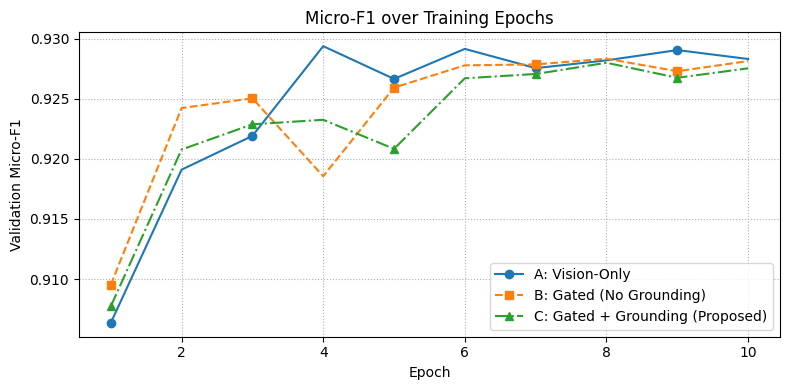

In [ ]:
# ── Fig 1: Validation Micro-F1 over epochs ────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

linestyles = ['-', '--', '-.']
markers    = ['o', 's', '^']
labels_plot = ['A: Vision-Only', 'B: Gated (No Grounding)', 'C: Gated + Grounding (Proposed)']

for hist, ls, mk, lbl in zip(
    [history_A, history_B, history_C], linestyles, markers, labels_plot
):
    epochs = [e['epoch'] for e in hist]
    f1s    = [e['micro_f1'] for e in hist]
    ax.plot(epochs, f1s, linestyle=ls, marker=mk, label=lbl, markevery=2)

ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Micro-F1')
ax.set_title('Micro-F1 over Training Epochs')
ax.legend()
ax.grid(True, linestyle=':')
plt.tight_layout()
fig.savefig('fig1_micro_f1_epochs.png', dpi=300)
plt.show()

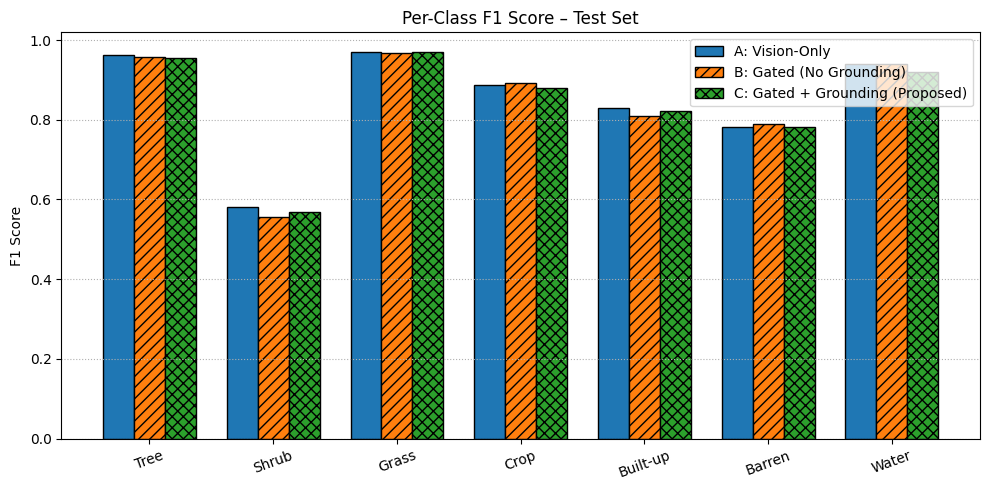

In [ ]:
# ── Fig 2: Per-class F1 bar chart ─────────────────────────────────────────────
x     = np.arange(len(CLASSES))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
hatches = ['', '///', 'xxx']

for i, (exp_name, lbl, hatch) in enumerate(
    zip(results.keys(), labels_plot, hatches)
):
    vals = [results[exp_name][f'f1_{cls}'] for cls in CLASSES]
    ax.bar(x + i * width, vals, width, label=lbl, hatch=hatch, edgecolor='black')

ax.set_xticks(x + width)
ax.set_xticklabels(CLASSES, rotation=20)
ax.set_ylabel('F1 Score')
ax.set_title('Per-Class F1 Score – Test Set')
ax.legend()
ax.grid(axis='y', linestyle=':')
plt.tight_layout()
fig.savefig('fig2_per_class_f1.png', dpi=300)
plt.show()

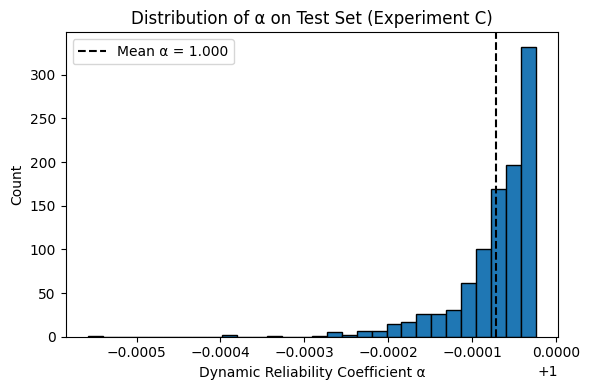

In [ ]:
# ── Fig 3: Alpha distribution for Experiment C ────────────────────────────────
# Collect α values on the test set for qualitative analysis
model_C.eval()
alpha_vals = []

with torch.no_grad():
    for batch in test_loader:
        imgs     = batch['image'].to(DEVICE)
        ids      = batch['input_ids'].to(DEVICE)
        attn_msk = batch['attn_mask'].to(DEVICE)
        _, alpha, _ = model_C(imgs, ids, attn_msk)
        alpha_vals.append(alpha.cpu().squeeze(1).numpy())

alpha_vals = np.concatenate(alpha_vals)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(alpha_vals, bins=30, edgecolor='black')
ax.set_xlabel('Dynamic Reliability Coefficient α')
ax.set_ylabel('Count')
ax.set_title('Distribution of α on Test Set (Experiment C)')
ax.axvline(alpha_vals.mean(), color='k', linestyle='--', label=f'Mean α = {alpha_vals.mean():.3f}')
ax.legend()
plt.tight_layout()
fig.savefig('fig3_alpha_distribution.png', dpi=300)
plt.show()

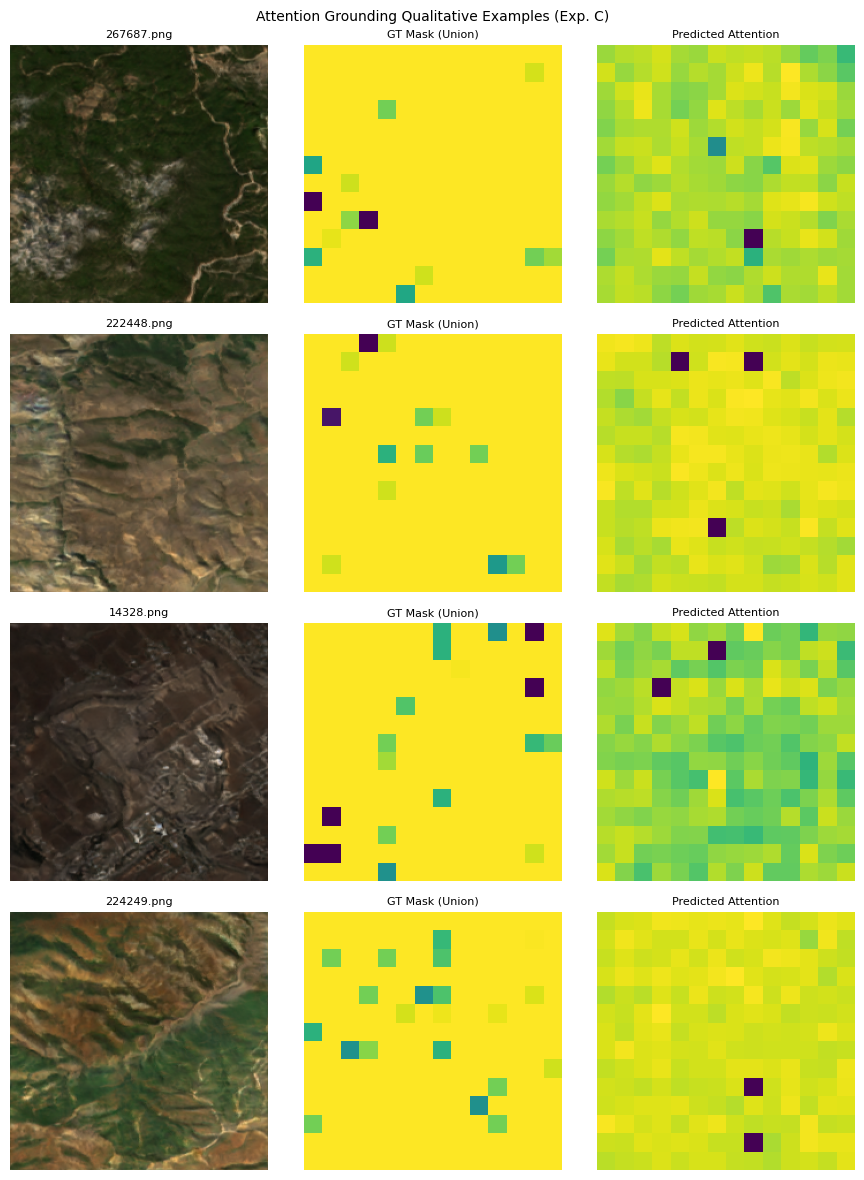

In [ ]:
# ── Fig 4: Attention map visualisation ────────────────────────────────────────
# Show 4 test examples: original image, GT mask, and predicted attention map

model_C.eval()
sample_batch = next(iter(test_loader))
imgs_raw  = sample_batch['image'][:4]
ids_s     = sample_batch['input_ids'][:4].to(DEVICE)
attn_s    = sample_batch['attn_mask'][:4].to(DEVICE)
gt_attn_s = sample_batch['gt_attn'][:4]       # (4, C, 14, 14)
labels_s  = sample_batch['labels'][:4]
fnames    = sample_batch['filename'][:4]

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

with torch.no_grad():
    _, _, pred_attn = model_C(imgs_raw.to(DEVICE), ids_s, attn_s)
    pred_attn = pred_attn.cpu()

fig, axes = plt.subplots(4, 3, figsize=(9, 12))
for i in range(4):
    # Denormalise image
    img_show = (imgs_raw[i] * IMAGENET_STD + IMAGENET_MEAN).clamp(0, 1).permute(1, 2, 0).numpy()

    # GT union mask (presence-weighted)
    presence = labels_s[i].unsqueeze(-1).unsqueeze(-1)  # (C, 1, 1)
    gt_union  = (gt_attn_s[i] * presence).max(dim=0).values.numpy()

    axes[i, 0].imshow(img_show)
    axes[i, 0].set_title(f'{fnames[i]}', fontsize=8)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(gt_union, cmap='viridis', vmin=0, vmax=1)
    axes[i, 1].set_title('GT Mask (Union)', fontsize=8)
    axes[i, 1].axis('off')

    axes[i, 2].imshow(pred_attn[i].numpy(), cmap='viridis', vmin=0, vmax=1)
    axes[i, 2].set_title('Predicted Attention', fontsize=8)
    axes[i, 2].axis('off')

fig.suptitle('Attention Grounding Qualitative Examples (Exp. C)', fontsize=10)
plt.tight_layout()
fig.savefig('fig4_attention_grounding_examples.png', dpi=300)
plt.show()

## 10. Preliminary Conclusions

This cell summarises the key findings from Phase 2, to be refined for the written report.

- **Experiment A (Vision-Only)** serves as the baseline. It has no access to captions and no gate.
- **Experiment B (Gated, no grounding)** tests whether multi-modal fusion via the reliability gate alone improves classification. A higher Micro-F1 over A would confirm the value of text integration.
- **Experiment C (Gated + Grounding)** is the full proposed method. The attention grounding loss encourages the ViT's attention to focus on semantically relevant regions as defined by the segmentation masks.

The **Dynamic Reliability Coefficient α** distribution (Fig 3) provides interpretability: values clustered near 0.5 suggest the model balances both modalities, while values near 0 or 1 reveal which modality the model prefers per sample.

These results will feed directly into the Phase 3 ablation study, where ATTN_LOSS_W (λ) will be systematically varied.